# DoroMarine — Data Import & Cleaning

In [138]:
import pandas as pd
import json

df = pd.read_csv("DoroMarine.csv")
df = df[['messages', 'from_messenger']]
print(df.shape)
df.head(2)


(1170, 2)


,messages,from_messenger
0,"[{""key"":""v1"",""date"":""2025-07-17T12:40:45.519Z""...",instagram
1,"[{""key"":""v1"",""date"":""2025-07-17T12:42:02.117Z""...",instagram


In [139]:
df['from_messenger'].value_counts()

from_messenger
instagram     1160
telegramm        9
ChatWindow       1
Name: count, dtype: int64

In [140]:
# 1. Define a robust JSON parser that won't crash the notebook on NaN or bad text
def parse_and_count(val):
    if pd.isna(val) or not isinstance(val, str):
        return 0
    try:
        parsed = json.loads(val)
        return len(parsed) if parsed is not None else 0
    except json.JSONDecodeError:
        return 0  # Returns 0 if the string isn't valid JSON


# 2. Create the new column directly
# Replace 'json_string_column' with the actual name of your column
df["message_count"] = df["messages"].apply(parse_and_count)

# 3. Preview the results
df[["messages", "message_count"]].head()

df['message_count'].describe()

count    1170.000000
mean        5.895726
std         8.164230
min         1.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        82.000000
Name: message_count, dtype: float64

In [141]:
# 1. Define a robust JSON parser that won't crash the notebook on NaN or bad text
def parse_and_count(val):
    if pd.isna(val) or not isinstance(val, str):
        return 0
    try:
        parsed = json.loads(val)
        parsed_clean = [msg for msg in parsed if msg.get('role') in ['user', 'assistant'] ]
        return len(parsed_clean) if parsed_clean is not None else 0
    except json.JSONDecodeError:
        return 0  # Returns 0 if the string isn't valid JSON


# 2. Create the new column directly
# Replace 'json_string_column' with the actual name of your column
df["message_count_clean"] = df["messages"].apply(parse_and_count)

# 3. Preview the results
df[["messages", "message_count_clean"]].head()

df['message_count_clean'].describe()

count    1170.000000
mean        4.614530
std         6.925805
min         1.000000
25%         1.000000
50%         3.000000
75%         4.750000
max        73.000000
Name: message_count_clean, dtype: float64

/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_4571/1642210806.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="message_count_clean", ax=axes[1], palette="Set2")


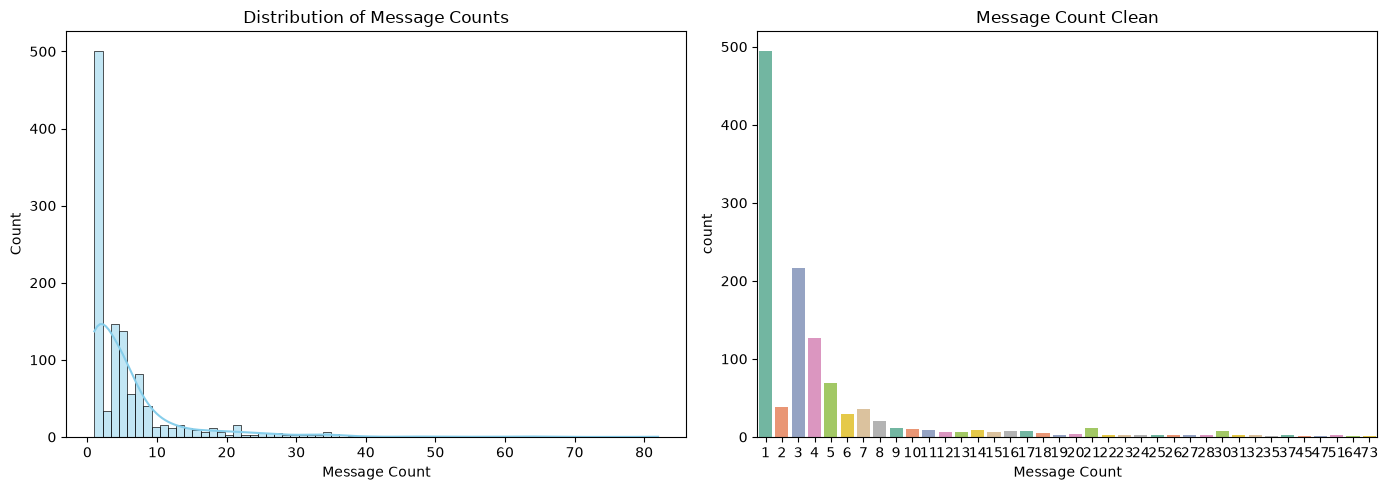

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2. Left Plot: First column distribution
sns.histplot(data=df, x="message_count", ax=axes[0], color="skyblue", kde=True)
axes[0].set_title("Distribution of Message Counts")
axes[0].set_xlabel("Message Count")


# 3. Right Plot: Second column distribution (e.g., your messenger platforms)
# We use countplot here because it automatically counts categorical values
sns.countplot(data=df, x="message_count_clean", ax=axes[1], palette="Set2")
axes[1].set_title("Message Count Clean")
axes[1].set_xlabel("Message Count")


# Clean up layout adjustments and display
plt.tight_layout()
plt.show()

In [143]:
mask = df['message_count'] > 4

sample = df[mask]

# 1. Parse the string to a Python object (dictionary/list)
data_to_save = json.loads(sample["messages"].iloc[0])

# 2. Write it cleanly to a file
with open("sample_message.json", "w", encoding="utf-8") as f:
    json.dump(data_to_save, f, indent=4, ensure_ascii=False)

In [144]:
import json
import pandas as pd


def check_for_tool_calls(val):
    if pd.isna(val) or not isinstance(val, str):
        return 0
    try:
        parsed = json.loads(val)

        if isinstance(parsed, list):
            # Check if ANY message in the list contains a 'tool_calls' key that isn't empty
            for msg in parsed:
                if isinstance(msg, dict):
                    # Check if 'tool_calls' key exists and has items, OR if the role itself is 'tool'
                    if msg.get("role") == "tool_calls":
                        return 1  # Return 1 immediately if found

        return 0  # Return 0 if loop finishes and no tool calls were found
    except json.JSONDecodeError:
        return 0


# 2. Create the new column directly
df["success"] = df["messages"].apply(check_for_tool_calls)

# 3. Preview the results & summary statistics
print(df["success"].describe())
df[["messages", "success"]].head()

mask_success = df['success'] == 1
df_success = df[mask_success]

df_success.head(5)


count    1170.000000
mean        0.165812
std         0.372071
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: success, dtype: float64


,messages,from_messenger,message_count,message_count_clean,success
14,"[{""key"":""v1"",""date"":""2025-07-21T05:52:21.086Z""...",instagram,6,3,1
45,"[{""key"":""v1"",""date"":""2025-07-04T17:37:26.507Z""...",instagram,14,8,1
46,"[{""key"":""v1"",""date"":""2025-06-26T18:42:38.190Z""...",instagram,9,6,1
70,"[{""key"":""v1"",""date"":""2025-06-27T04:28:28.772Z""...",instagram,14,10,1
72,"[{""key"":""v1"",""date"":""2025-07-08T12:33:02.638Z""...",instagram,29,25,1


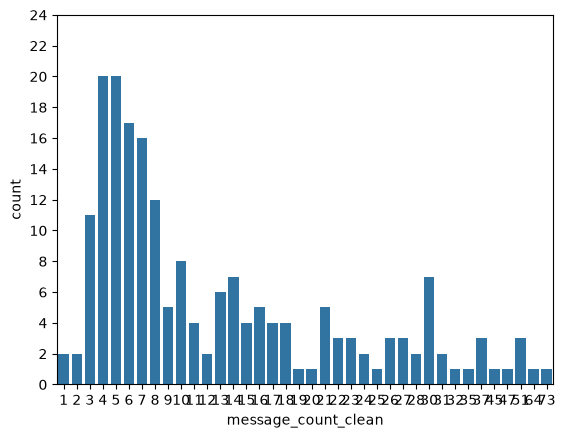

In [153]:
sns.countplot(data=df_success, x="message_count_clean")

# 2. Set y-axis ticks from 0 to 600, stepping by 50
# (Make sure 'stop' is slightly higher than your maximum count)
plt.yticks(range(0, 25, 2))

plt.show()